In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('../8/titanic.csv', usecols=['Survived', 'number'])

In [9]:
df.head()

,number,Survived
0,5,0
1,3,1
2,6,1
3,3,1
4,A,0


In [10]:
df.sample(3)

,number,Survived
292,4,0
655,5,0
418,1,0


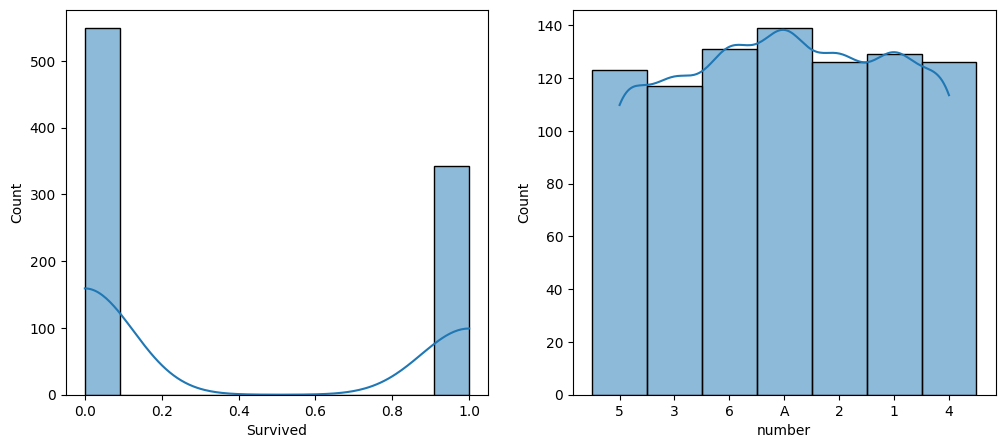

In [17]:
plt.figure(figsize=(12,5))      # 12 width aur 5 height ka figure create karta hai

plt.subplot(1,2,1)             # 1 row, 2 columns me plots divide karta hai, aur 1st plot select karta hai

sns.histplot(df['Survived'], kde=True)   # 'Survived' column ka distribution plot dikhata hai
                               # 0 = Not Survived
                               # 1 = Survived
                               # Titanic dataset me ye binary column hai

plt.subplot(1, 2, 2)
sns.histplot(df['number'], kde=True)     # 'number' column ka distribution plot dikhata hai
plt.show()

In [24]:
df['Survived'].skew()

# Skewness measures how much a distribution is asymmetric (tilted).

# skew ≈ 0  -> Data is approximately symmetric/normal.

# skew > 0  -> Right-skewed distribution.
#             Tail is longer on the right side.
#             May indicate some large values or possible outliers.

# skew < 0  -> Left-skewed distribution.
#             Tail is longer on the left side.
#             May indicate some small values or possible outliers.

np.float64(0.4785234382949897)

In [25]:
print(df['Survived'].mean())
print(df['Survived'].std())
print(df['Survived'].min())
print(df['Survived'].max())

0.3838383838383838
0.4865924542648575
0
1


# Z-Score / 3-Sigma Formula

Boundary nikalne ke liye:

### Upper Limit=μ+3σ

### Lower Limit=μ−3σ

Jahan:

μ (Mean) = Average
σ (Standard Deviation) = Spread of data

In [27]:
# Finding the boundary values

print("Highest allowed", df['Survived'].mean() + 3 * df['Survived'].std())
print("Lowest allowed", df['Survived'].mean() - 3 * df['Survived'].std())

Highest allowed 1.8436157466329564
Lowest allowed -1.0759389789561886


In [29]:
df[(df['Survived'] > 1.8) | (df['Survived'] < -0.8)]
# Checking for outliers in the 'Survived' column using upper and lower limits.

,number,Survived


# Trimming

In [30]:
new_df = df[(df['Survived'] <= 1.8) & (df['Survived'] >= -0.8)]

In [31]:
new_df

,number,Survived
0,5,0
1,3,1
2,6,1
3,3,1
4,A,0
...,...,...
886,3,0
887,3,1
888,1,0
889,2,1


In [34]:
# Approach 2

# Calculating the Zscore

df['Survived_zscore'] = (df['Survived'] - df['Survived'].mean()) / df['Survived'].std()

# z = (x-μ​) / σ
# X = Current value
# μ (Mean) = Average
# σ (Standard Deviation) = Data ka spread
# Z = Value mean se kitni standard deviations door hai

In [35]:
df.head()

,number,Survived,Survived_p_zscore,Survived_zscore
0,5,0,-0.788829,-0.788829
1,3,1,1.266279,1.266279
2,6,1,1.266279,1.266279
3,3,1,1.266279,1.266279
4,A,0,-0.788829,-0.788829


In [36]:
# No, 3 is not fixed. It is a commonly used threshold based on the 3-sigma rule. Depending on the problem and domain, thresholds such as ±2, ±2.5, or ±3 may be used.
# Z-score method → Usually ±3
# IQR method → 1.5 × IQR

df[df['Survived_zscore'] > 3]

,number,Survived,Survived_p_zscore,Survived_zscore


In [37]:
df[df['Survived_zscore'] < -3]

,number,Survived,Survived_p_zscore,Survived_zscore


In [38]:
df[(df['Survived_zscore'] > 3) | (df['Survived_zscore'] < -3)]

,number,Survived,Survived_p_zscore,Survived_zscore


In [39]:
new_df = df[(df['Survived_zscore'] > 3) & (df['Survived_zscore'] < -3)]

In [40]:
new_df

,number,Survived,Survived_p_zscore,Survived_zscore


# Capping (Winsorization) 

### Capping me row delete nahi karte.
### Outlier value ko boundary value se replace kar dete hain.

In [41]:
upper_limit = df['Survived'].mean() + 3 * df['Survived'].std()
lower_limit = df['Survived'].mean() - 3 * df['Survived'].std()

In [42]:
lower_limit

np.float64(-1.0759389789561886)

In [43]:
upper_limit

np.float64(1.8436157466329564)

In [45]:
df['Survived'] = np.where(
    df['Survived'] > upper_limit,
    upper_limit,
    np.where(
        df['Survived'] < lower_limit,
        lower_limit,
        df['Survived']
    )
)

In [46]:
df.shape

(891, 4)

In [47]:
df['Survived'].describe()

count    891.000000
mean       0.383838
std        0.486592
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000
Name: Survived, dtype: float64